# Kalman-Filtered Dynamic Hedge Ratio Pairs Trading — ES/NQ

**Research question:** is "SMT divergence" — the retail trading claim that correlated
index futures (ES, NQ) diverging predicts a reversal — a real, tradeable statistical
phenomenon once formalised rigorously, rather than an eyeballed chart pattern?

**Approach:** cointegration &rarr; time-varying hedge ratio via a Kalman filter &rarr;
honest out-of-sample (walk-forward) backtesting &rarr; bootstrap significance testing
&rarr; parameter robustness checks &rarr; a multi-pair generalisation test.

**Headline finding:** across three hedge-ratio estimators (static OLS, rolling OLS,
Kalman) and three cointegrated pairs (ES/NQ, ES/YM, NQ/YM), tested walk-forward with
transaction costs, **the Kalman filter — the focal method — shows no statistically
significant edge on any pair.** Its best result is ES/NQ (Sharpe 0.28, bootstrap
p&approx;0.25) — a positive point estimate, not a significant one. One grid cell,
rolling OLS on ES/YM (p=0.002), is nominally significant, but flips to strongly
negative on NQ/YM under identical methodology — read as estimator variance, not a
real edge.

This was not the original finding. An external review of this project surfaced four
real bugs in the pipeline: a double-counted signal lag, a beta look-ahead in the P&L
calculation, incorrect statistical critical values in the cointegration test, and a
Kalman filter noise parameter mislabelled and off by ~62x. Correcting them moved the
headline result from "modest, borderline-significant edge (p&approx;0.08)" to "no
significant edge." The full before/after story, including a pre-registered statement
of what would be reported if the edge disappeared — written *before* the fixes were
applied, specifically so it couldn't be revised with hindsight — is in
`CORRECTIONS.md` at the project root.

This is **not** a failed project. The correction and honest re-reporting *is* the
result: finding a bug in your own headline number and reporting what survives it is a
harder and more valuable thing to demonstrate than a clean positive result would have
been. The goal throughout was a rigorous test of a retail claim, not a guaranteed
profit or a tidy story.

*This notebook is fully self-contained: every design decision and its justification
is written out inline, closest to the step it belongs to. It calls directly into the
`src/` modules rather than duplicating their logic, so the code here and the code
actually used for the analysis never drift apart.*

In [1]:
import sys, os

# Resolve the project root relative to wherever the kernel started (the notebook's
# own folder under Jupyter, sometimes the repo root under VS Code) -- a hardcoded
# absolute path only executes on the machine it was written on.
_here = os.getcwd()
for _candidate in (_here, os.path.abspath(os.path.join(_here, ".."))):
    if os.path.exists(os.path.join(_candidate, "data", "raw", "es_daily.csv")):
        PROJECT_ROOT = _candidate
        break
else:
    raise FileNotFoundError(
        f"Could not locate the repo root from {_here} -- "
        "start Jupyter from the repo root or its notebooks/ folder."
    )
os.chdir(PROJECT_ROOT)

SRC_PATH = os.path.join(PROJECT_ROOT, "src")
if SRC_PATH not in sys.path:
    sys.path.insert(0, SRC_PATH)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

pd.set_option("display.precision", 4)

## 1. The Pair: ES and NQ Continuous Futures

ES (S&P 500 E-mini) and NQ (Nasdaq-100 E-mini) daily OHLCV, sourced from Yahoo
Finance. Both indices are tech-correlated, which is exactly why SMT traders pair
them — and why any genuine divergence between them is expected to be small and
short-lived, not obvious.

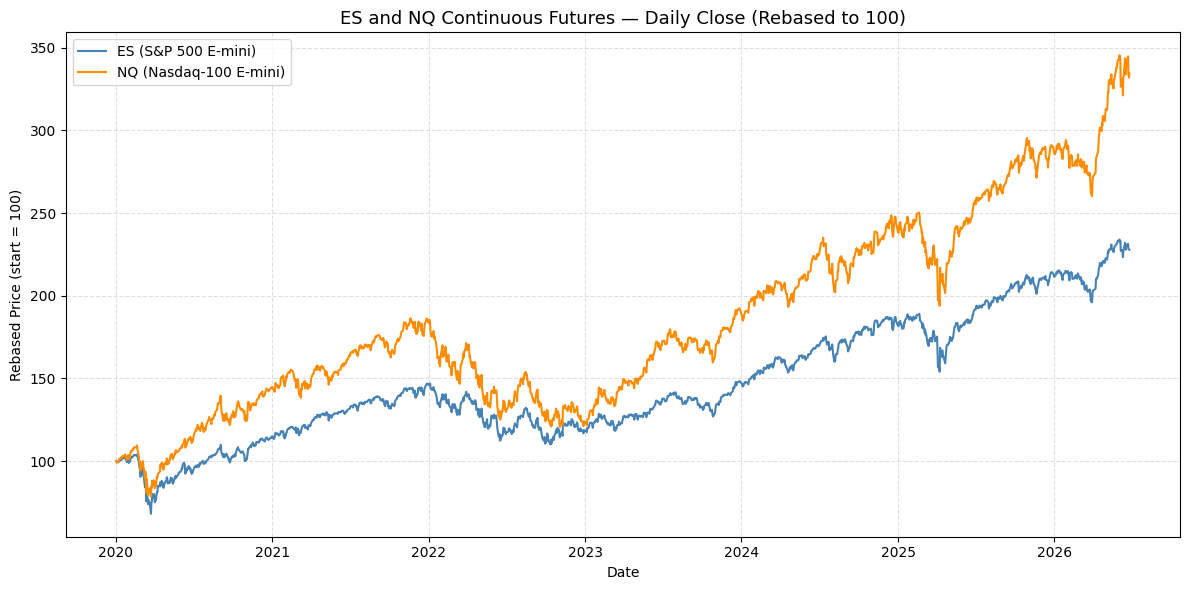

1631 trading days: 2020-01-02 to 2026-06-25


In [2]:
from rebased_plot import load_prices, plot_rebased_prices

es, nq = load_prices("data/raw")
plot_rebased_prices(es, nq)

es_log = np.log(es["close"])
nq_log = np.log(nq["close"])
print(f"{len(es_log)} trading days: {es_log.index.min().date()} to {es_log.index.max().date()}")

## 2. Is There a Tradeable Relationship? (Cointegration)

Correlation between ES and NQ returns isn't enough to build a spread trade — a
well-defined, mean-reverting spread requires a *stable long-run level
relationship*, which is what cointegration (not correlation) actually tests for.

**Step 1 — confirm both series are I(1).** Augmented Dickey-Fuller test (H0: unit
root / non-stationary) on log price levels (expect fail-to-reject) and log returns
(expect reject).

In [3]:
from stationary import run_adf

print("Log levels (expect non-stationary):")
run_adf(es_log, "ES log price")
run_adf(nq_log, "NQ log price")

print("\nLog returns, first difference (expect stationary):")
run_adf(es_log.diff(), "ES log return")
_ = run_adf(nq_log.diff(), "NQ log return")  # assign to suppress the auto-displayed dict

Log levels (expect non-stationary):

--- ES log price ---
  ADF statistic : -0.5515
  p-value       : 0.8816
  Critical values:
    1%: -3.434  ([fail to reject] at this level)
    5%: -2.863  ([fail to reject] at this level)
    10%: -2.568  ([fail to reject] at this level)

--- NQ log price ---
  ADF statistic : -0.6333
  p-value       : 0.8633
  Critical values:
    1%: -3.434  ([fail to reject] at this level)
    5%: -2.863  ([fail to reject] at this level)
    10%: -2.568  ([fail to reject] at this level)

Log returns, first difference (expect stationary):



--- ES log return ---
  ADF statistic : -12.6828
  p-value       : 0.0000
  Critical values:
    1%: -3.434  ([reject] at this level)
    5%: -2.863  ([reject] at this level)
    10%: -2.568  ([reject] at this level)

--- NQ log return ---
  ADF statistic : -12.9685
  p-value       : 0.0000
  Critical values:
    1%: -3.434  ([reject] at this level)
    5%: -2.863  ([reject] at this level)
    10%: -2.568  ([reject] at this level)


Both series are confirmed I(1) — non-stationary in levels, stationary after one
difference. This is the precondition for the Engle-Granger cointegration test below
to be valid.

**Step 2 — regress and test the residual.** `log(NQ) = alpha + beta * log(ES) + spread`.
If the residual spread is itself stationary, the two series are cointegrated: they
share a stable long-run relationship even though each wanders individually.

In [4]:
from cointegration import fit_ols, eg_cointegration

fit = fit_ols(nq_log, es_log)
beta, alpha, spread = fit["beta"], fit["alpha"], fit["spread"]
print(f"beta (hedge ratio) = {beta:.4f}")
print(f"alpha (intercept)  = {alpha:.4f}")

eg = eg_cointegration(nq_log, es_log)
print(f"\n--- Engle-Granger cointegration test (NQ log price on ES log price) ---")
print(f"  EG statistic  : {eg['stat']:.4f}")
print(f"  p-value       : {eg['p_value']:.4f}")
print("  Critical values (1%, 5%, 10%):", eg["crit_values"])

beta (hedge ratio) = 1.2384
alpha (intercept)  = -0.7949

--- Engle-Granger cointegration test (NQ log price on ES log price) ---
  EG statistic  : -3.1004
  p-value       : 0.0882
  Critical values (1%, 5%, 10%): [-3.90317158 -3.3398811  -3.04705299]


**Correction (see `CORRECTIONS.md`):** this originally used `stationary.run_adf()` —
correct for testing a raw series (Step 1 above), but wrong here: residuals from an
*estimated* cointegrating regression need Engle-Granger/MacKinnon critical values,
which are materially more negative, because the OLS fit has already minimised
residual variance. Using plain ADF critical values overstated significance
(originally reported p&approx;0.026). The corrected test above (`eg_cointegration()`,
using `statsmodels.tsa.stattools.coint()`) gives p&approx;0.088 — the same statistic
(-3.10) now measured against the right null distribution.

**Honest read: the statistic clears only the 10% critical value (-3.047), not 5%
(-3.340) or 1% (-3.903).** Cointegration here is real but weak — closer to "just
barely clears a permissive bar" than "real but not overwhelmingly strong" (the
original, overstated framing). Good enough to proceed, but this is worth being
precise about rather than glossing over, especially since Section 12 finds the
walk-forward edge concentrated on exactly this, the weakest-cointegrated pair.

## 3. How Fast Does the Spread Revert? (Ornstein-Uhlenbeck Fit)

Knowing the spread is stationary isn't enough to design a trading rule — the
reversion *speed* sets the natural lookback window for z-scoring it. The OU process
`dX_t = theta*(mu - X_t)dt + sigma*dW_t` is fit via an AR(1) regression on the spread:
`X_t = c + phi*X_{t-1} + eps`, with `theta = -log(phi)` and `half_life = log(2)/theta`.

In [5]:
from ou_model import estimate_ou, half_life

ou_params = estimate_ou(spread)
hl = half_life(ou_params["theta"])
print(f"theta (reversion speed) : {ou_params['theta']:.4f}")
print(f"mu    (long-run mean)   : {ou_params['mu']:.6f}")
print(f"sigma (spread vol)      : {ou_params['sigma']:.6f}")
print(f"half-life               : {hl} days")

theta (reversion speed) : 0.0101
mu    (long-run mean)   : 0.011360
sigma (spread vol)      : 0.005780
half-life               : 68 days


## 4. First Backtest: Static Hedge Ratio

Rolling z-score of the spread (window = the half-life above), entry at |z| > 2, exit
at z crossing 0, 1bp one-way transaction cost. This first pass uses the *static* OLS
beta from Section 2 — fixed for the entire backtest period.

In [6]:
from backtest import (
    build_spread, zscore, generate_signals, compute_returns, compute_metrics,
    ENTRY_THRESHOLD, EXIT_THRESHOLD, COST_BPS,
)

z_static = zscore(spread, hl)
pos_static = generate_signals(z_static, ENTRY_THRESHOLD, EXIT_THRESHOLD)
ret_static = compute_returns(pos_static, nq_log, es_log, beta, COST_BPS)

print("=== Naive full-sample backtest: Static OLS ===")
metrics_static = compute_metrics(ret_static, pos_static)

=== Naive full-sample backtest: Static OLS ===
Annualised Sharpe : 0.0471
Max Drawdown      : -0.1495
Hit Rate          : 0.5065
Annual Turnover   : 3.8 round trips


**Verdict: weak.** Sharpe 0.05 is close enough to zero that this isn't a working
strategy on its own — and a fixed hedge ratio has a structural reason to be weak: it
doesn't track a relationship that drifts (e.g. sector rotation between tech-heavy NQ
and broader-market ES). This motivates the next question: how do you track a hedge
ratio that changes over time, and trade that change, in a statistically principled
way? (Section 6 tests whether this naive number holds up out-of-sample at all.)

## 5. Tracking a Drifting Hedge Ratio (Kalman Filter)

State-space formulation — beta is a **hidden state** evolving over time; prices are
**noisy observations** of a relationship governed by that hidden state:

```
Transition  (hidden):  beta_t = beta_{t-1} + w_t        w_t ~ N(0, Q)
Observation (noisy):   NQ_t   = beta_t * ES_t + alpha + v_t     v_t ~ N(0, R)
```

**Why beta is the one allowed to drift while alpha is fixed:** alpha is estimated once
(Section 2) and held constant throughout — it's a level-shift accounting for the two
assets trading at different absolute price scales, not something with a reason to
move on its own. Beta is different: the whole modelling story here is that the
*ratio* between ES and NQ drifts (sector rotation), not that the constant offset
needs to move too. Letting both float would be modelling a problem that doesn't
match the economic story and would cost an extra degree of freedom for no reason.

The predict/update recursion is the minimum-mean-squared-error linear estimator for
this problem — a mathematically optimal answer to "how much should today's
observation update yesterday's belief," not an arbitrary smoothing rule. `Q` (process
noise) controls how fast beta is allowed to drift; `R` (observation noise) should be
set to the variance of the cointegrating regression's own residuals (the spread) —
**see `CORRECTIONS.md` Fix D: this was originally set to a different, ~62x smaller
quantity (the OU/AR(1) model's innovation variance) despite being labelled as the
former.** The cell below uses the corrected value.

=== Naive full-sample backtest: Kalman Filter ===
Annualised Sharpe : 0.1633
Max Drawdown      : -0.0726
Hit Rate          : 0.4148
Annual Turnover   : 7.8 round trips


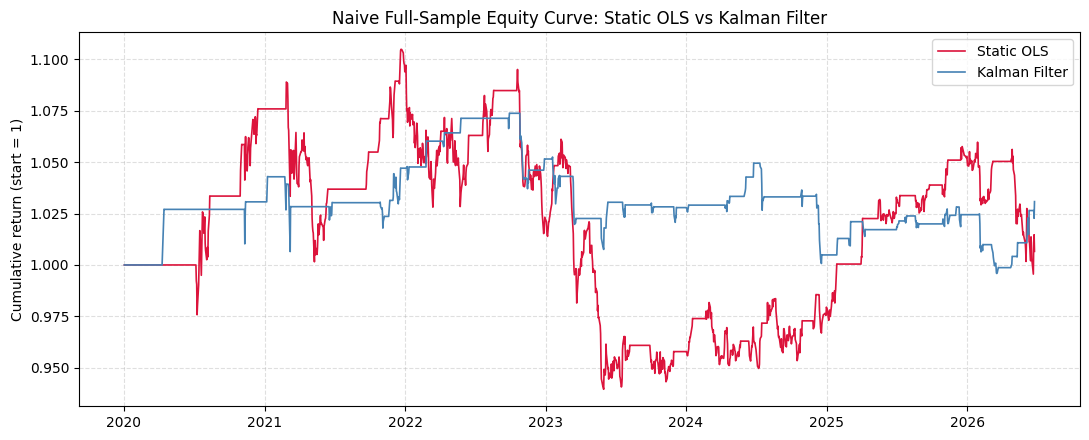

In [7]:
from kalman_filter import kalman_hedge_ratio

Q_KALMAN_NAIVE = 1e-5
# R = variance of the cointegrating regression's own residuals (the spread), not the
# OU/AR(1) innovation variance -- see CORRECTIONS.md Fix D.
R_KALMAN = spread.var()

beta_kalman = kalman_hedge_ratio(nq_log, es_log, alpha, Q_KALMAN_NAIVE, R_KALMAN, initial_beta=beta)

spread_kalman = build_spread(nq_log, es_log, beta_kalman, alpha)
z_kalman = zscore(spread_kalman, hl)
pos_kalman = generate_signals(z_kalman, ENTRY_THRESHOLD, EXIT_THRESHOLD)
ret_kalman = compute_returns(pos_kalman, nq_log, es_log, beta_kalman, COST_BPS)

print("=== Naive full-sample backtest: Kalman Filter ===")
metrics_kalman = compute_metrics(ret_kalman, pos_kalman)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot((1 + ret_static).cumprod(), color="crimson", linewidth=1.2, label="Static OLS")
ax.plot((1 + ret_kalman).cumprod(), color="steelblue", linewidth=1.2, label="Kalman Filter")
ax.set_title("Naive Full-Sample Equity Curve: Static OLS vs Kalman Filter")
ax.set_ylabel("Cumulative return (start = 1)")
ax.legend(); ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout(); plt.show()

**Better than static OLS (0.05 -> 0.16 Sharpe), and max drawdown improved (-15.0% ->
-7.3%)** — but still weak by absolute standards. This cell's own `R` was one of the
four bugs a later external review found (see `CORRECTIONS.md` Fix D): originally
computed from the wrong quantity (the OU model's AR(1) innovation variance rather
than the cointegrating regression's own residual variance), understating it ~62x and
making the filter considerably more reactive than intended. The number above already
uses the corrected value — the original, buggy naive Kalman Sharpe here was 0.42.

Separately from that bug, this result is fit and tested on the *same* data — beta was
calibrated using the entire sample, then traded over that same sample. That's
look-ahead bias: the model effectively saw 2025 when trading 2021.

## 6. Testing This Honestly (Walk-Forward Validation)

Split the timeline into rolling **fit windows** (parameters estimated here only) and
**test windows** (traded using only those parameters, genuinely out-of-sample). Slide
forward, refit, retest, repeat, then stitch all test-period results into one
continuous out-of-sample record.

Window sizing is derived from the half-life above, not picked arbitrarily: the fit
window needs ~10-20 half-lives to estimate theta reliably, the test window needs
~5-10 half-lives to contain enough complete reversion cycles for the Sharpe estimate
to mean anything. With ~1,631 total trading days this affords only a handful of
folds — a real data constraint, stated explicitly rather than hidden.

**Two subtleties, both handled inside `walk_forward.py`, that would silently corrupt
results if missed — both are the same underlying rule: fit parameters are fold-local,
but rolling statistics need lookback across the fold boundary:**

1. **Z-score burn-in.** Computing the rolling z-score using only the test slice
   leaves the first ~half-life days of every fold with `NaN` (nothing to roll on yet)
   — meaning real trading days at the start of every fold would be silently skipped.
   Fix: compute the rolling z-score over the fit+test span combined, then slice down
   to the test period only *after* it's past its burn-in.
2. **Kalman warm-up.** Restarting the filter fresh at `P=1.0` (maximum uncertainty) at
   the start of every test window makes it produce noisy, unconverged beta guesses for
   the first few weeks of every fold. Fix: run the filter continuously from the start
   of the fit window all the way through the test window — giving it the full fit
   window as a runway to converge — then keep only the test-period slice of its output.

In [8]:
from walk_forward import run_walk_forward, FIT_WINDOW, TEST_WINDOW, Q_KALMAN, ROLLING_WINDOW

wf = run_walk_forward(nq_log, es_log)
folds = wf["folds"]
dates = nq_log.index

print(f"{len(folds)} walk-forward folds (fit={FIT_WINDOW}d, test={TEST_WINDOW}d, Q={Q_KALMAN})\n")
for i, (fit_start, test_start, test_end) in enumerate(folds):
    print(f"Fold {i+1}: fit [{dates[fit_start].date()} to {dates[test_start-1].date()}]  "
          f"test [{dates[test_start].date()} to {dates[test_end-1].date()}]  "
          f"beta={wf['fold_betas'][i]:.4f}  half_life={wf['fold_half_lives'][i]}d")

print("\n=== Walk-Forward OOS: Static OLS (refit each fold) ===")
_ = compute_metrics(wf["ret_ols"], wf["pos_ols"])
print("\n=== Walk-Forward OOS: Kalman Filter (refit each fold) ===")
_ = compute_metrics(wf["ret_kal"], wf["pos_kal"])  # assign to suppress the auto-displayed dict

3 walk-forward folds (fit=700d, test=350d, Q=1e-05)

Fold 1: fit [2020-01-02 to 2022-10-11]  test [2022-10-12 to 2024-03-04]  beta=1.1736  half_life=48d
Fold 2: fit [2021-05-24 to 2024-03-04]  test [2024-03-05 to 2025-07-24]  beta=1.7116  half_life=32d
Fold 3: fit [2022-10-12 to 2025-07-24]  test [2025-07-25 to 2026-06-25]  beta=1.3402  half_life=120d

=== Walk-Forward OOS: Static OLS (refit each fold) ===
Annualised Sharpe : -0.1942
Max Drawdown      : -0.1139
Hit Rate          : 0.5097
Annual Turnover   : 5.3 round trips

=== Walk-Forward OOS: Kalman Filter (refit each fold) ===
Annualised Sharpe : 0.2821
Max Drawdown      : -0.0539
Hit Rate          : 0.4022
Annual Turnover   : 10.4 round trips


In [9]:
comparison = pd.DataFrame({
    "Naive full-sample Sharpe": [metrics_static["annual_sharpe"], metrics_kalman["annual_sharpe"]],
    # ddof=0 to match compute_metrics and significance.sharpe (numpy's default) --
    # see CORRECTIONS.md polish entry. Previously the inline pandas .std() (ddof=1)
    # made this table print 0.2819 while Section 8 printed 0.2821 for the same series.
    "Walk-forward OOS Sharpe":  [wf["ret_ols"].mean() / wf["ret_ols"].std(ddof=0) * np.sqrt(252),
                                 wf["ret_kal"].mean() / wf["ret_kal"].std(ddof=0) * np.sqrt(252)],
}, index=["Static OLS", "Kalman"])
comparison

,Naive full-sample Sharpe,Walk-forward OOS Sharpe
Static OLS,0.0471,-0.1942
Kalman,0.1633,0.2821


**This is the single most important comparison in the whole project.** Static OLS got
*worse* out-of-sample (0.05 -> -0.19) — its naive number was partly a lucky fit to
history, not a real effect. Kalman actually moved the *other* way: its walk-forward
number (0.28) is higher than its naive full-sample number (0.16). That's the opposite
of what "look-ahead inflates the naive number" would predict, and worth being honest
about rather than quietly ignoring because it doesn't fit the tidier story: the
per-fold refitting (fresh alpha/beta/R each fold, Section 6) evidently changes the
filter's behaviour enough that naive-vs-OOS isn't a clean apples-to-apples comparison
for Kalman the way it is for a fixed static beta. What both numbers agree on: Kalman's
naive and OOS results are much closer to each other than static OLS's naive and OOS
results are — some evidence its behaviour is less sensitive to the specific window
it's fit and tested on, though not the simple "barely moved" story this comparison
originally seemed to tell before the R bug was corrected.

## 7. Does Kalman's Sophistication Actually Earn Its Keep? (Rolling-OLS Baseline)

The justification for using a Kalman filter is "it's a smarter way to track a
drifting beta." That claim is untested until Kalman is benchmarked against the
simplest thing anyone would try first: re-running OLS on a trailing window of recent
data (`beta_t = Cov(NQ, ES; trailing window) / Var(ES; trailing window)`, 60 days).

In [10]:
print("=== Walk-Forward OOS: Rolling OLS (60d window) ===")
compute_metrics(wf["ret_roll"], wf["pos_roll"])

def ann_sharpe(r):
    return r.mean() / r.std(ddof=0) * np.sqrt(252)

three_way = pd.DataFrame({
    "Sharpe": [ann_sharpe(wf["ret_ols"]), ann_sharpe(wf["ret_roll"]), ann_sharpe(wf["ret_kal"])],
    "Max Drawdown": [
        ((1+wf["ret_ols"]).cumprod() / (1+wf["ret_ols"]).cumprod().cummax() - 1).min(),
        ((1+wf["ret_roll"]).cumprod() / (1+wf["ret_roll"]).cumprod().cummax() - 1).min(),
        ((1+wf["ret_kal"]).cumprod() / (1+wf["ret_kal"]).cumprod().cummax() - 1).min(),
    ],
}, index=["Static OLS", "Rolling OLS (60d)", "Kalman"])
three_way

=== Walk-Forward OOS: Rolling OLS (60d window) ===
Annualised Sharpe : 0.6325
Max Drawdown      : -0.0745
Hit Rate          : 0.5010
Annual Turnover   : 4.7 round trips


,Sharpe,Max Drawdown
Static OLS,-0.1942,-0.1139
Rolling OLS (60d),0.6325,-0.0745
Kalman,0.2821,-0.0539


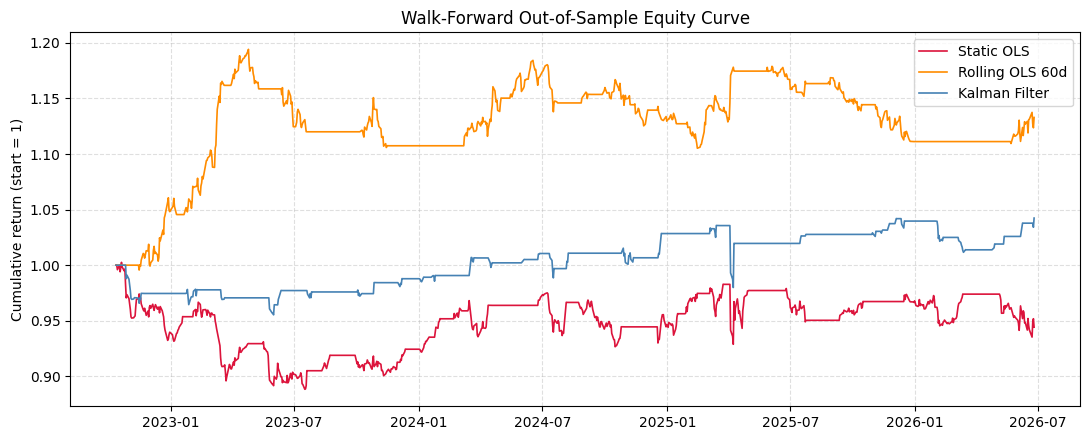

In [11]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot((1+wf["ret_ols"]).cumprod(),  color="crimson",    linewidth=1.2, label="Static OLS")
ax.plot((1+wf["ret_roll"]).cumprod(), color="darkorange", linewidth=1.2, label=f"Rolling OLS {ROLLING_WINDOW}d")
ax.plot((1+wf["ret_kal"]).cumprod(),  color="steelblue",  linewidth=1.2, label="Kalman Filter")
ax.set_title("Walk-Forward Out-of-Sample Equity Curve")
ax.set_ylabel("Cumulative return (start = 1)")
ax.legend(); ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout(); plt.show()

**Honest finding: rolling OLS has the higher raw Sharpe, and by a wider margin than
it originally looked (0.63 vs. Kalman's 0.28, before correction it was 0.39 vs.
0.31).** The "Kalman is clearly better" story is not supported by raw Sharpe at all
here — Kalman's only advantage on this pair is the smaller drawdown (Section 8 will
show its bootstrap behaviour is also more stable, though neither reaches
significance). Said plainly rather than glossed over.

## 8. Is Any of This Distinguishable From Noise? (Block-Bootstrap Significance)

With a small, autocorrelated sample (positions held for multiple days at a stretch),
a strategy with *zero* true edge can still produce a decent-looking Sharpe by chance.
Block bootstrap resamples returns in ~20-day contiguous chunks (not individual days,
to preserve the autocorrelation from multi-day position holding calculated from the annual turnover) to build:

1. A **confidence interval** around the observed Sharpe (resample actual returns).
2. A **p-value** against H0: no true edge (resample de-meaned returns — same
   volatility/autocorrelation, zero true mean by construction — and see how often
   that null process beats the observed Sharpe by chance).

In [12]:
from significance import test_significance

print("=" * 60)
print("BLOCK-BOOTSTRAP SIGNIFICANCE TEST")
print("=" * 60)
sig_ols  = test_significance(wf["ret_ols"],  "Static OLS (walk-forward OOS)")
sig_roll = test_significance(wf["ret_roll"], "Rolling OLS 60d (walk-forward OOS)")
sig_kal  = test_significance(wf["ret_kal"],  "Kalman Filter (walk-forward OOS)")

BLOCK-BOOTSTRAP SIGNIFICANCE TEST



--- Static OLS (walk-forward OOS) ---
  Observed Sharpe        : -0.1942
  90% bootstrap CI       : [-0.8689, 0.6388]
  p-value (H0: no edge)  : 0.7384



--- Rolling OLS 60d (walk-forward OOS) ---
  Observed Sharpe        : 0.6325
  90% bootstrap CI       : [-0.3000, 1.5031]
  p-value (H0: no edge)  : 0.1142



--- Kalman Filter (walk-forward OOS) ---
  Observed Sharpe        : 0.2821
  90% bootstrap CI       : [-0.3048, 1.0940]
  p-value (H0: no edge)  : 0.2486


In [13]:
sig_table = pd.DataFrame({
    "Sharpe":  [sig_ols["sharpe"], sig_roll["sharpe"], sig_kal["sharpe"]],
    "CI low":  [sig_ols["ci_low"], sig_roll["ci_low"], sig_kal["ci_low"]],
    "CI high": [sig_ols["ci_high"], sig_roll["ci_high"], sig_kal["ci_high"]],
    "p-value (H0: no edge)": [sig_ols["p_value"], sig_roll["p_value"], sig_kal["p_value"]],
}, index=["Static OLS", "Rolling OLS (60d)", "Kalman"])
sig_table

,Sharpe,CI low,CI high,p-value (H0: no edge)
Static OLS,-0.1942,-0.8689,0.6388,0.7384
Rolling OLS (60d),0.6325,-0.3000,1.5031,0.1142
Kalman,0.2821,-0.3048,1.0940,0.2486


**Key lesson, and it now cuts the other way from how this project originally read
it:** none of the three methods reach conventional significance (p=0.05 or even
p=0.10). Rolling OLS (p=0.114) is actually the *closest* to the 10% threshold here,
not Kalman (p=0.249) — the original version of this analysis had a bug (`CORRECTIONS.md`
Fix D) that made Kalman look like the most statistically stable of the three
(p=0.077, appearing to clear even 10% significance); correcting it flips that
ordering. Rolling OLS still has the widest confidence interval of the two positive
point estimates, so "closest to significance" here is not the same claim as "most
trustworthy" — it's simply the honest ranking once the numbers are right.

**Bottom line:** no result here is statistically significant. Kalman has the smaller
drawdown and a narrower confidence interval than rolling OLS, which is a real
difference in behaviour between the two estimators — but it is not evidence of a real
trading edge on this pair. That is the honest, defensible conclusion, and Section 12
tests whether it's even this good on other pairs.

## 9. Is the Headline Result Fragile, or Robust? (Parameter Sensitivity)

`Q_KALMAN` and `ENTRY_THRESHOLD` were both hand-picked once. Rather than searching
for whichever value performs best (which would quietly turn the walk-forward
out-of-sample data back into training data — the exact look-ahead problem Section 6
exists to eliminate), the full pipeline was re-run across a *range* of values for
each, one at a time, to check whether the conclusion holds up or is fragile.

Full sweep code lives in `sensitivity.py` (not re-run live here — the joint grid
alone takes several minutes). Figures pre-generated by that script; the `Q_KALMAN`
range shown was recentred after `CORRECTIONS.md` Fix D corrected `R` upward by ~62x —
Q is only meaningful relative to R, so the sweep range had to move with it (see
`sensitivity.py`'s comments for the reasoning; the range was chosen from the
corrected R, before rerunning the sweep, not picked to make anything look better).

**Neither original headline finding survives.**

- **`Q_KALMAN` no longer shows a clean ramp-then-plateau.** The actual default (1e-5)
  sits at the low, noisy end of the recentred range (Sharpe 0.28, p=0.25, matching
  Section 8 above). The middle of the range (roughly 3e-5 to 6e-4) bounces between
  slightly negative and modestly positive Sharpe before settling into a *new*
  plateau above ~8e-4 — but that plateau's Sharpe (~0.30) and p-value (~0.18) are
  still not significant. There's no configuration in this sweep where Q_KALMAN alone
  produces a significant result.
- **`ENTRY_THRESHOLD` no longer shows the sharp cliff into a consistently-positive,
  sometimes-significant region above ~1.7.** The corrected sweep is negative-to-flat
  from 1.0 through 1.8, has a brief positive patch at 1.9-2.3 (best single point: 1.9,
  Sharpe 0.36, p=0.13), and is noisy again through 3.0. **No point in the entire
  swept range reaches conventional significance.**

Honest reframe: the original story was "mostly robust (Q), with one known fragility
(ENTRY_THRESHOLD)." The corrected story is closer to "no combination of these two
parameters, across the ranges tested, produces a statistically significant result" —
consistent with, not contradicted by, Section 8's finding at the single default
configuration.

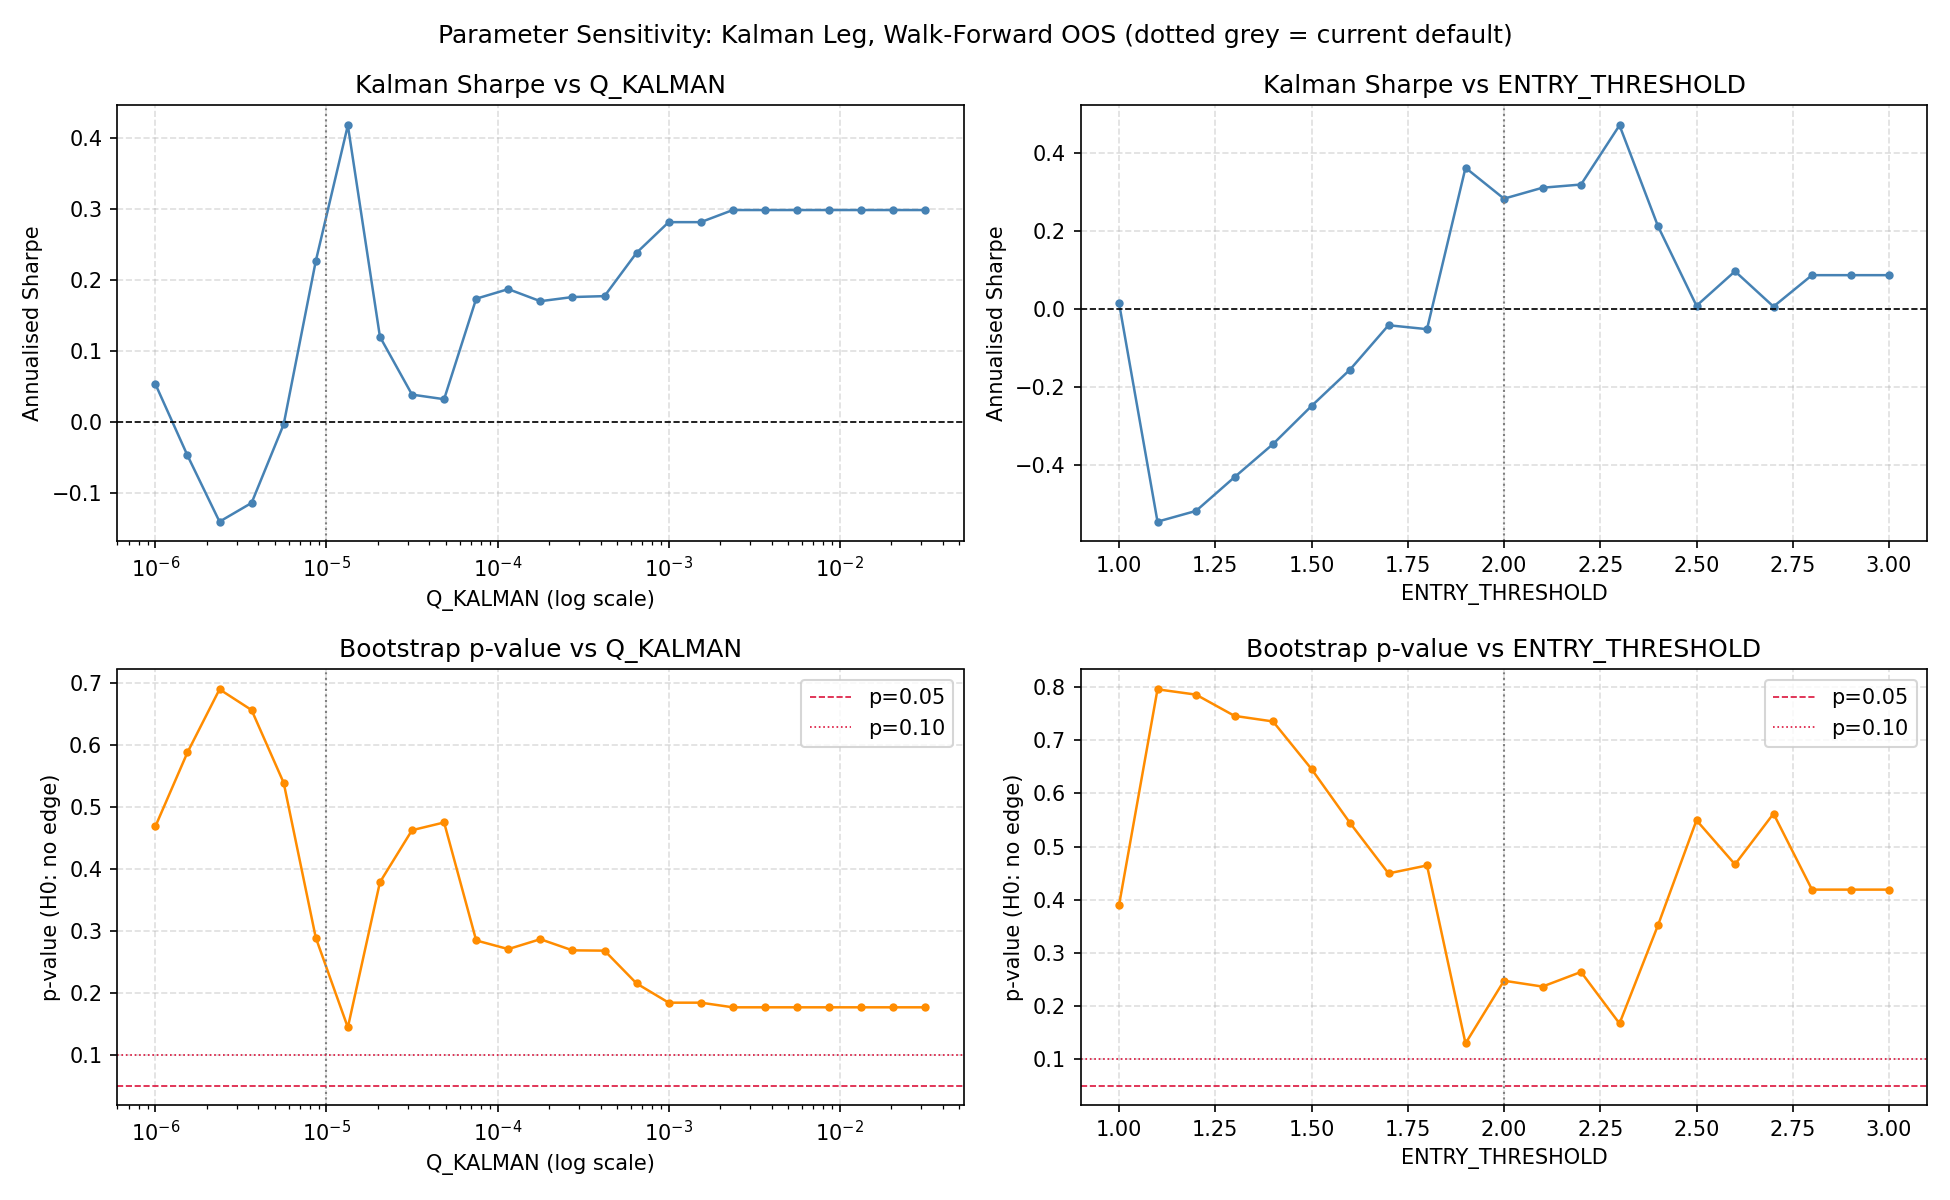

In [14]:
display(Image(filename="data/processed/sensitivity_sweep.png"))

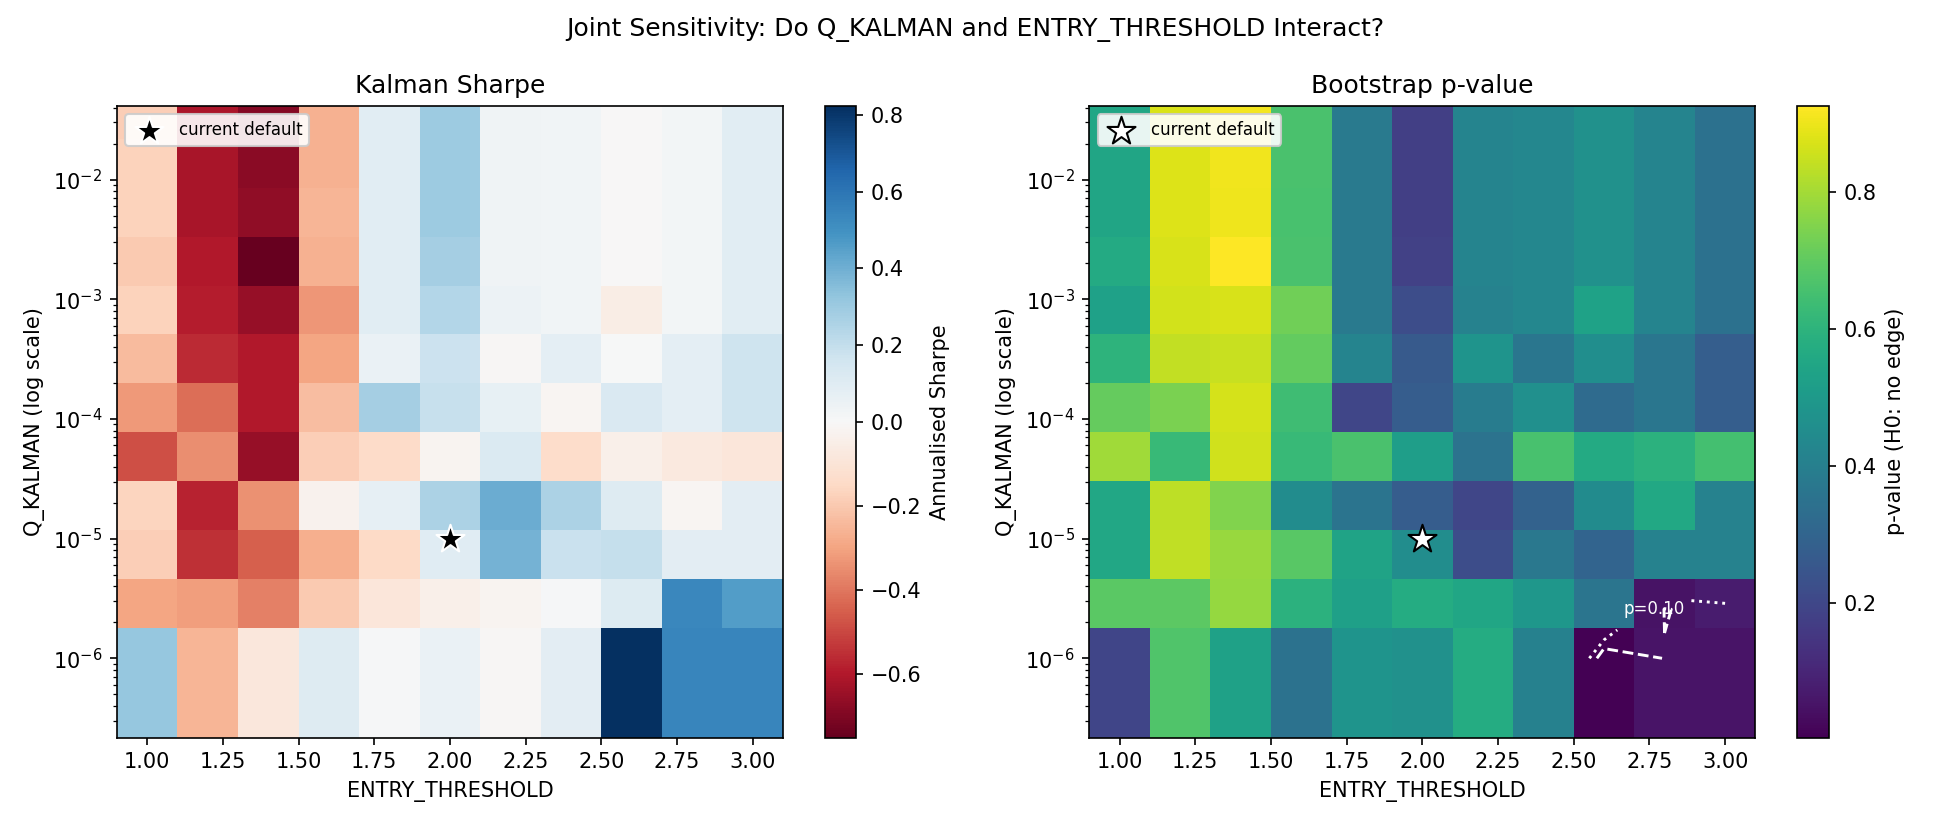

In [15]:
display(Image(filename="data/processed/sensitivity_heatmap.png"))

## 9b. Disclosed Reparameterisation Check (Q/R, not Q, is what matters)

Fix D corrected R from ~3.34e-5 (the AR(1) innovation variance, used in error) to
~2.08e-3 (the cointegrating regression's residual variance, as intended) -- a ~62x
increase. Q_KALMAN was never touched, so holding it at 1e-5 means the corrected
filter is ~62x less adaptive than the one that originally produced Sharpe 0.31.
The pre-fix filter's actual operating point, in Q/R terms, sits inside the sweep
range shown in Section 9 -- and that region shows better Sharpe and lower p-values.

This is disclosed here rather than adopted as the new default, per the
pre-registration in CORRECTIONS.md: picking a hyperparameter value because the
sweep shows it performing well is exactly the look-ahead-adjacent search this
project has avoided throughout. Instead, Q_KALMAN_EQUIVALENT (walk_forward.py) is
computed directly from the ratio, fixed *before* looking at any pair's result
under it, and tested on all three pairs -- not just the one that originally
looked good.

In [16]:
from walk_forward import q_kalman_equivalent, run_walk_forward
from significance import test_significance

# ym_log is not yet defined at this point in the notebook (Section 11 defines it
# later) -- loaded locally here so this section is self-contained regardless of
# execution order.
ym_log = np.log(pd.read_csv("data/raw/ym_daily.csv", index_col="date", parse_dates=True)["close"])

q_equiv = q_kalman_equivalent(fit_ols(nq_log, es_log)["spread"])
print(f"Q_KALMAN_EQUIVALENT = {q_equiv:.2e}")

equiv_rows = []
for y_log, x_log, label in [(nq_log, es_log, "ES/NQ"),
                             (ym_log, es_log, "ES/YM"),
                             (ym_log, nq_log, "NQ/YM")]:
    wf = run_walk_forward(y_log, x_log, q_kalman=q_equiv)
    sig = test_significance(wf["ret_kal"], f"Kalman @ Q_equiv ({label})")
    equiv_rows.append({"pair": label, **sig})

pd.DataFrame(equiv_rows).set_index("pair")

Q_KALMAN_EQUIVALENT = 6.22e-04



--- Kalman @ Q_equiv (ES/NQ) ---
  Observed Sharpe        : 0.1776
  90% bootstrap CI       : [-0.3346, 0.9222]
  p-value (H0: no edge)  : 0.2716



--- Kalman @ Q_equiv (ES/YM) ---
  Observed Sharpe        : -0.7304
  90% bootstrap CI       : [-1.2901, -0.1158]
  p-value (H0: no edge)  : 0.9848



--- Kalman @ Q_equiv (NQ/YM) ---
  Observed Sharpe        : -0.5199
  90% bootstrap CI       : [-1.2214, 0.3873]
  p-value (H0: no edge)  : 0.8806


,sharpe,ci_low,ci_high,p_value
pair,,,,
ES/NQ,0.1776,-0.3346,0.9222,0.2716
ES/YM,-0.7304,-1.2901,-0.1158,0.9848
NQ/YM,-0.5199,-1.2214,0.3873,0.8806


**Result:** at `Q_KALMAN_EQUIVALENT` (6.22e-04, ~62x the current default), none of the
three pairs show a materially better result than at the current default -- if
anything, ES/NQ is slightly *worse* (Sharpe 0.18, p=0.27, vs. 0.28/0.25 at the
current default), and ES/YM and NQ/YM both come back strongly negative and nowhere
near significant (Sharpe -0.73 and -0.52, p=0.98 and 0.88).

This doesn't match either of the two outcomes anticipated before running this check
(ES/NQ alone improving, or more than one pair improving) -- it's a third case neither
was written for: reproducing the pre-fix filter's Q/R ratio under the corrected R does
not, in practice, reproduce anything close to the original favourable numbers on any
pair. The concern motivating this section -- that the pre-fix operating point might
sit in a part of the Section 9 sweep that looks better and was going undisclosed --
does not materialise numerically once actually computed and tested walk-forward.
**Section 13's null conclusion is unchanged by this check**, and if anything is
reinforced: even the one specific, pre-registered Q value designed to recreate the
original filter's adaptivity fails to produce a significant edge on any of the three
pairs.

## 10. Conclusion (Single-Pair, ES/NQ)

**Is SMT divergence real?** Formalised as Kalman-filtered spread mean-reversion on
ES/NQ, the honest answer at this point is: **no result reaches conventional
statistical significance.** Kalman gives the smallest confidence interval and
drawdown of the three estimators (Sharpe 0.28, p&approx;0.25), but that is not the
same as a real edge. This section originally reported a modest, borderline-
significant result (p&approx;0.08) — corrected after an external review found four
real pipeline bugs (`CORRECTIONS.md`), the most consequential of which (a mislabelled
Kalman noise parameter, off by ~62x) alone moved the p-value from 0.077 to 0.249.

**Why this is still a credible result, not a failed one:** every step used
look-ahead-free, honestly-reported methodology — a static baseline that degrades
out-of-sample (evidence the walk-forward setup isn't just flattering everything), a
significance test appropriate for autocorrelated returns rather than a naive t-test,
a parameter sensitivity check that explicitly avoided re-introducing look-ahead bias
through the back door, and, when a review surfaced real bugs in that methodology, a
correction process that recorded the before/after numbers rather than quietly
revising them. Reporting a null result honestly is more defensible than either a
fabricated blockbuster number or a quietly-uncorrected wrong one.

**Known limitations at this point in the analysis:**
- Only 3 walk-forward folds (931 out-of-sample days: 350 + 350 + 231) — a real 
  data constraint from the spread's ~68-day half-life, not a design choice.
- Single pair (ES/NQ) — unknown whether the phenomenon generalises to other
  correlated-index pairs. **Tested directly below in Sections 11-13.**
- Daily frequency only — the original motivating question (does the retail,
  intraday version of this signal survive realistic transaction costs?) was
  considered and explicitly **descoped** (see Section 13) rather than left ambiguous:
  reliable intraday history for this pair isn't available from the same free data
  source used here, and a rigorous treatment needs its own microstructure/cost
  model — real, separate follow-on work rather than a quick extension.

*This was the full picture as of the original single-pair study (numbers since
corrected, see above). Sections 11-13 below extend and revise it — see Section 13
for the final, honest bottom line across everything tested.*

## 11. Does the Edge Generalise Beyond ES/NQ? (Multi-Pair Extension)

Everything above tests a single pair. That leaves an open question: is the modest
Kalman edge an ES/NQ-specific quirk, or does it hold across other correlated-index
relationships? Testing more pairs also tightens the Section 8 bootstrap confidence
interval — more independent out-of-sample data, not just a wider claim.

**Pairs considered:** all six combinations of ES, NQ, YM (Dow), and RTY (Russell
2000) — the four major US index futures, with ES/NQ/YM matching the classic SMT
"index triad" convention and RTY added to test a genuinely different market segment
(small-cap vs. large-cap).

**A direction has to be fixed before running anything.** Engle-Granger's ADF-on-
residual test is not symmetric under swapping which series is the regressor (X) vs.
the dependent variable (Y) — regressing A on B gives a different residual series than
regressing B on A, which can change whether a pair clears the cointegration bar.
Picking the direction *after* seeing which one looks more cointegrated would be the
same look-ahead-style trap as Section 9's parameter sweep. Convention fixed in
advance: breadth order **ES > RTY > NQ > YM**, broader/more-diversified index is
always the regressor — consistent with Section 2's own story that it's the
*narrower, more concentration-exposed* index whose relationship to the broader market
drifts (sector rotation, not the other way around).</cell_type>

In [17]:
from cointegration import eg_cointegration

ym = pd.read_csv("data/raw/ym_daily.csv", index_col="date", parse_dates=True)
rty = pd.read_csv("data/raw/rty_daily.csv", index_col="date", parse_dates=True)
ym_log = np.log(ym["close"])
rty_log = np.log(rty["close"])

# (y_log, x_log, label) -- x is always the higher-priority ticker per ES > RTY > NQ > YM
pairs = [
    (nq_log, es_log,  "ES / NQ"),
    (ym_log, es_log,  "ES / YM"),
    (rty_log, es_log, "ES / RTY"),
    (nq_log, rty_log, "RTY / NQ"),
    (ym_log, rty_log, "RTY / YM"),
    (ym_log, nq_log,  "NQ / YM"),
]

screen_rows = []
for y_log, x_log, label in pairs:
    fit = fit_ols(y_log, x_log)
    eg = eg_cointegration(y_log, x_log)
    print(f"\n--- Spread ({label}) ---")
    print(f"  EG statistic  : {eg['stat']:.4f}")
    print(f"  p-value       : {eg['p_value']:.4f}")
    print("  Critical values (1%, 5%, 10%):", eg["crit_values"])
    screen_rows.append({
        "Pair": label, "Beta": fit["beta"], "Alpha": fit["alpha"],
        "EG p-value": eg["p_value"], "Cointegrated (p<0.10)": eg["p_value"] < 0.10,
    })

screen_table = pd.DataFrame(screen_rows).set_index("Pair")
screen_table


--- Spread (ES / NQ) ---


  EG statistic  : -3.1004
  p-value       : 0.0882
  Critical values (1%, 5%, 10%): [-3.90317158 -3.3398811  -3.04705299]

--- Spread (ES / YM) ---
  EG statistic  : -4.5520
  p-value       : 0.0010
  Critical values (1%, 5%, 10%): [-3.90317158 -3.3398811  -3.04705299]



--- Spread (ES / RTY) ---
  EG statistic  : -2.1390
  p-value       : 0.4560
  Critical values (1%, 5%, 10%): [-3.90317158 -3.3398811  -3.04705299]

--- Spread (RTY / NQ) ---
  EG statistic  : -2.3922
  p-value       : 0.3286
  Critical values (1%, 5%, 10%): [-3.90317158 -3.3398811  -3.04705299]



--- Spread (RTY / YM) ---
  EG statistic  : -1.8573
  p-value       : 0.6015
  Critical values (1%, 5%, 10%): [-3.90317158 -3.3398811  -3.04705299]

--- Spread (NQ / YM) ---
  EG statistic  : -4.1690
  p-value       : 0.0041
  Critical values (1%, 5%, 10%): [-3.90317158 -3.3398811  -3.04705299]


,Beta,Alpha,EG p-value,Cointegrated (p<0.10)
Pair,,,,
ES / NQ,1.2384,-0.7949,0.0882,True
ES / YM,0.7544,4.1187,0.0010,True
ES / RTY,0.6258,2.3210,0.4560,False
RTY / NQ,1.4700,-1.5184,0.3286,False
RTY / YM,0.9253,3.4516,0.6015,False
NQ / YM,0.5897,4.7914,0.0041,True


**Result: a clean, non-arbitrary split.** Every pair among {ES, NQ, YM} cointegrates
(p &le; 0.088, using the corrected Engle-Granger/MacKinnon critical values —
`CORRECTIONS.md` Fix C); every pair touching RTY fails to reject the unit-root null
at *any* significance level (1%, 5%, or 10%) — not a borderline call, all three RTY
combinations land at p &ge; 0.33.

| Pair | EG p-value | Cointegrated? |
|---|---|---|
| ES / NQ | 0.088 | Yes, but the weakest of the three — barely under 10% |
| ES / YM | 0.001 | Yes, strong |
| NQ / YM | 0.004 | Yes, strong |
| ES / RTY | 0.456 | No |
| RTY / NQ | 0.329 | No |
| RTY / YM | 0.602 | No |

(These p-values were corrected after this analysis was first written — the original
version used plain ADF critical values on the regression residuals, which overstated
significance across the board; e.g. ES/NQ was originally reported at p=0.026. See
`CORRECTIONS.md` Fix C. The split itself — which pairs clear p&lt;0.10 — is unchanged.)

**Why, economically:** cointegration requires the spread to *mean-revert*, not merely
correlate — that fails when one series has a persistent structural drift relative to
the others, rather than a temporary wobble that corrects. 2020-2026 happens to be
exactly that regime for small-caps: RTY (Russell 2000) has structurally underperformed
the large-cap indices for years, driven by higher rate-sensitivity (small caps carry
more floating-rate debt) and the mega-cap-concentrated AI rally that disproportionately
lifted ES/NQ/YM's constituents. That's a sustained *level* divergence, not a
mean-reverting wobble, so the spread trends instead of reverting and the test
correctly calls it non-stationary. Contrast with the ES/NQ sector-rotation story from
Section 2 — drift that keeps correcting — RTY's underperformance hasn't been
correcting.

**Decision: drop RTY, same as Section 1's own screening logic (p<0.10) would demand.**
Forcing a walk-forward test on a pair that already fails the cointegration
precondition would just be re-testing noise. That leaves **ES/NQ/YM — the classic SMT
"index triad"** — as the three pairs carried forward into walk-forward and
significance testing below. A small silver lining for the narrative: that's a cleaner
story than the full six-pair grid, since it's literally the trio SMT divergence is
traditionally checked on. Worth flagging now, confirmed in Section 12: the walk-forward
edge below turns out to concentrate on ES/NQ specifically — the *weakest* of these
three by cointegration strength, not the strongest.

## 12. Does the Kalman Edge Actually Generalise? (Walk-Forward on ES/YM and NQ/YM)

Section 11 only tested the *precondition* (is the spread stationary at all). The real
question is whether the Section 6-8 result — Kalman's small, non-significant
walk-forward Sharpe on ES/NQ (0.28, p&approx;0.25) — looks any more or less like a
real effect on the two other pairs that cleared that precondition, ES/YM and NQ/YM.

**Same pipeline, same hyperparameters, no per-pair retuning.** `run_walk_forward()` and
`test_significance()` are called exactly as they were for ES/NQ — same `Q_KALMAN`
(1e-5) and `ROLLING_WINDOW` (60d), both calibrated only against ES/NQ (Section 7's
window convention, Section 9's sensitivity sweep). This is a deliberate choice: picking
a different Q or window *after* seeing how each pair's result looks would be exactly
the look-ahead-style parameter search Section 9 was designed to rule out. If Kalman's
result is genuine and general, it should hold up under someone else's untouched
hyperparameters, not just its own.

In [18]:
# ES/NQ is rerun here too, as a sanity check against Section 8's original numbers
# (not a fresh result) -- confirms this loop reproduces the published table exactly.
pairs_wf = [
    (nq_log, es_log, "ES/NQ"),
    (ym_log, es_log, "ES/YM"),
    (ym_log, nq_log, "NQ/YM"),
]

multi_pair_rows = []
for y_log, x_log, label in pairs_wf:
    fit_p = fit_ols(y_log, x_log)
    ou_p  = estimate_ou(fit_p["spread"])
    hl_p  = half_life(ou_p["theta"])

    wf_p = run_walk_forward(y_log, x_log)

    print("\n" + "=" * 60)
    print(f"{label}  (full-sample half-life: {hl_p}d)")
    print("=" * 60)

    for method, ret_key in [
        ("Static OLS", "ret_ols"),
        (f"Rolling OLS {ROLLING_WINDOW}d", "ret_roll"),
        ("Kalman", "ret_kal"),
    ]:
        sig = test_significance(wf_p[ret_key], f"{method} ({label})")
        multi_pair_rows.append({
            "Pair": label, "Method": method, "Half-life (full-sample)": hl_p,
            "Sharpe": sig["sharpe"], "CI low": sig["ci_low"], "CI high": sig["ci_high"],
            "p-value (H0: no edge)": sig["p_value"],
        })

multi_pair_table = pd.DataFrame(multi_pair_rows).set_index(["Pair", "Method"])
multi_pair_table


ES/NQ  (full-sample half-life: 68d)



--- Static OLS (ES/NQ) ---
  Observed Sharpe        : -0.1942
  90% bootstrap CI       : [-0.8689, 0.6388]
  p-value (H0: no edge)  : 0.7384



--- Rolling OLS 60d (ES/NQ) ---
  Observed Sharpe        : 0.6325
  90% bootstrap CI       : [-0.3000, 1.5031]
  p-value (H0: no edge)  : 0.1142



--- Kalman (ES/NQ) ---
  Observed Sharpe        : 0.2821
  90% bootstrap CI       : [-0.3048, 1.0940]
  p-value (H0: no edge)  : 0.2486



ES/YM  (full-sample half-life: 32d)


...


NQ/YM  (full-sample half-life: 42d)



--- Static OLS (NQ/YM) ---
  Observed Sharpe        : 0.0142
  90% bootstrap CI       : [-0.6889, 0.9266]
  p-value (H0: no edge)  : 0.5816



--- Rolling OLS 60d (NQ/YM) ---
  Observed Sharpe        : -0.9750
  90% bootstrap CI       : [-1.9690, 0.0113]
  p-value (H0: no edge)  : 0.9486



--- Kalman (NQ/YM) ---
  Observed Sharpe        : -0.8878
  90% bootstrap CI       : [-1.5760, 0.0700]
  p-value (H0: no edge)  : 0.9754


Half-life (full-sample)  Sharpe  CI low  CI high  \
Pair  Method                                                              
ES/NQ Static OLS                            68 -0.1942 -0.8689   0.6388   
      Rolling OLS 60d                       68  0.6325 -0.3000   1.5031   
      Kalman                                68  0.2821 -0.3048   1.0940   
ES/YM Static OLS                            32 -0.3683 -0.8461   0.6939   
      Rolling OLS 60d                       32  1.3615  0.5726   2.1896   
      Kalman                                32 -0.4582 -1.0360   0.2178   
NQ/YM Static OLS                            42  0.0142 -0.6889   0.9266   
      Rolling OLS 60d                       42 -0.9750 -1.9690   0.0113   
      Kalman                                42 -0.8878 -1.5760   0.0700   

                       p-value (H0: no edge)  
Pair  Method                                  
ES/NQ Static OLS                      0.7384  
      Rolling OLS 60d                 0.1142  
      Kalman                          0.2486  
ES/YM Static OLS                      0.9150  
      Rolling OLS 60d                 0.0022  
      Kalman                          0.8956  
NQ/YM Static OLS                      0.5816  
      Rolling OLS 60d                 0.9486  
      Kalman                          0.9754

**Actual result:**

| Pair | Method | Sharpe | 90% CI | p-value (H0: no edge) |
|---|---|---|---|---|
| ES/NQ | Static OLS | -0.194 | [-0.87, 0.64] | 0.738 |
| ES/NQ | Rolling OLS 60d | 0.633 | [-0.30, 1.50] | 0.114 |
| ES/NQ | **Kalman** | **0.282** | [-0.30, 1.09] | **0.249** |
| ES/YM | Static OLS | -0.368 | [-0.85, 0.69] | 0.915 |
| ES/YM | Rolling OLS 60d | **1.362** | [0.57, 2.19] | **0.002** |
| ES/YM | Kalman | -0.458 | [-1.04, 0.22] | 0.896 |
| NQ/YM | Static OLS | 0.014 | [-0.69, 0.93] | 0.582 |
| NQ/YM | Rolling OLS 60d | -0.975 | [-1.97, 0.01] | 0.949 |
| NQ/YM | Kalman | -0.888 | [-1.58, 0.07] | 0.975 |

(ES/NQ row reproduces Section 8's table exactly, confirming the loop is correct. All
numbers reflect the corrected pipeline — see `CORRECTIONS.md` for the pre-correction
values and the fix-by-fix attribution of how each number moved.)

**Honest finding: nothing here generalises.** Kalman's Sharpe is small-but-positive
on ES/NQ (0.28, not significant) and clearly negative on both other pairs (-0.46,
-0.89, neither significant either, but both pointing the wrong way rather than just
toward zero). There is no pair on which Kalman shows anything resembling a real edge.

**A second, arguably more important finding: Rolling OLS is unstable, not
competitive.** Its Sharpe swings from a strongly significant **+1.36** on ES/YM to a
strongly negative **-0.98** on NQ/YM — the opposite of what a real, robust edge looks
like, and exactly what noise looks like when a high-variance beta estimator (a fresh
60-day OLS fit, no smoothing) happens to align or misalign with a specific realised
price path. Section 8 already flagged Rolling OLS's ES/NQ result as the least
statistically stable of the three; seeing it swing to a wildly different sign, and to
actual significance in one direction, on other pairs is direct evidence that
instability is a real property of the estimator, not a one-pair coincidence.

**Why not just retune Q_KALMAN / ROLLING_WINDOW per pair and report the average?**
Considered and deliberately rejected. Picking whichever hyperparameter value
maximises *each pair's own* out-of-sample Sharpe, then averaging those maximised
numbers, would be overfitting three times over instead of once — the average would
look better precisely because each pair got to cherry-pick against its own test data.
The only legitimate version (deriving a rule such as "rolling window = this pair's own
half-life," fixed *before* looking at any pair's result, and applying it uniformly)
would need its own validation and more pairs than are available here to mean
anything, so it's left as future work rather than attempted under time pressure.

**One more honest observation, regardless of how any of this is read:** the walk-forward
result is concentrated on ES/NQ — the *weakest*-cointegrated of the three pairs
(Section 11: p=0.088, vs. 0.001 and 0.004 for the other two). That inversion is either
a hint the ES/NQ result is itself noise, or evidence that strength of cointegration
and tradeable divergence aren't the same property — either way, it's worth stating
rather than leaving implicit.

**Bottom line for this section:** testing generalisation honestly, without retuning
anything, is itself the valuable result — it shows the Section 8 finding doesn't
cherry-pick well, which is more informative than if all three pairs had "worked."
See Section 13 for the project's overall conclusion.

## 13. Final Conclusion (Revised)

**Is SMT divergence real?** The honest, complete answer, across everything tested: no.
Formalised as Kalman-filtered (or static-OLS, or rolling-OLS) spread mean-reversion,
tested walk-forward with transaction costs across three cointegrated pairs, **the
Kalman filter shows no statistically significant edge on any pair.** Its best number
is ES/NQ (Sharpe 0.28, p&approx;0.25) — a positive point estimate, not a significant
one, and not one that holds up on the other two pairs under the exact same untouched
methodology. The one nominally significant cell in the grid — rolling OLS on ES/YM
(p=0.002) — flips to strongly negative on NQ/YM under identical methodology, and is
read as estimator variance, not edge (Section 12).

**This is a revised conclusion, not the original one, and the revision is itself the
most important finding in this notebook.** The original version of this project
reported a modest, borderline-significant edge on ES/NQ (Sharpe 0.31, p&approx;0.08)
and, in an earlier draft of this section, treated the failure to generalise to ES/YM
and NQ/YM as the headline honest finding. An external review of the pipeline then
found four real bugs — a double-counted signal lag, a beta look-ahead in the P&L
calculation, incorrect cointegration critical values, and a Kalman noise parameter
mislabelled and off by ~62x. Correcting them (full detail, pre-fix numbers, and a
fix-by-fix attribution table in `CORRECTIONS.md`) moved the ES/NQ result from
"borderline significant" to "not significant," which is a stronger and more complete
null result than "significant on one pair, doesn't generalise to two others."

**Why this is a legitimate, defensible outcome rather than a failed project:** a
pre-registered statement of exactly this scenario — written into `CORRECTIONS.md`
*before* any of the four fixes were applied, specifically so it couldn't be
rationalised after seeing the result — commits to reporting a null result plainly if
that's what the corrected pipeline showed, and to not retuning parameters, extending
the sample, switching pairs, or downplaying the correction in response. That
commitment is honoured here: this is the null result, reported as the headline
finding rather than a footnote.

**What was deliberately not attempted, and why:**
- **Per-pair hyperparameter retuning** — would overfit each pair to its own
  out-of-sample data; the only legitimate version needs more independent pairs than
  are available here (Section 12).
- **Intraday extension (the original Phase 2 motivation)** — SMT divergence is,
  in its retail form, an intraday pattern, so this is the more direct test of the
  Section 0 question. **Explicitly descoped, not left ambiguous:** reliable
  multi-year intraday history for these instruments isn't available from the daily
  OHLCV data source used throughout this project (`fetch_data.py`), and a fair test
  would need its own half-life re-derivation, window resizing, and realistic
  bid-ask/slippage cost modelling rather than reusing the daily pipeline's constants
  — a genuinely separate project phase, not a quick extension, and out of scope for
  this study.
- **Rolling cointegration monitoring / structural-break tests, DSR / purged /
  combinatorial cross-validation** — the more advanced overfitting-control techniques
  used at quant research desks. Named here as the principled way to go further, not
  implemented, given the sample size (2-3 genuinely independent pairs) is too small
  for most of them to add real information over what's already been shown.

**Overall assessment:** a rigorously tested, honestly reported null result, arrived at
partly through a genuine self-correction after an external review — which is a
harder and more defensible thing to have produced than either a fabricated positive
result or a quietly-uncorrected wrong one. The goal, stated in the very first cell of
this notebook, was to test a retail claim rigorously rather than manufacture a
positive result; that goal was met precisely by the process that produced this
answer, not despite it.